In [ ]:
import warnings
warnings.filterwarnings(action='ignore')

# 엑셀 업무 자동화 

- 엑셀은 직장에서 가장 많이 사용하는 프로그램 중 하나로 쉽고 빠르게 연산 작업을 할 수 있고 간단한 데이터베이스 기능까지 활용할 수 있습니다
- 엑셀로 하는 다른 반복적인 일이나 대량의 데이터를 처리할 때는 파이썬을 활용하면 좀 더 편하고 스마트하게 작업을 할 수 있습니다.
- 엑셀, 파워포인트, 워드 파일과 같이 오피스 프로그램에서 만들어지는 문서 파일은 모두 Office Open XML(OOXML) 규약에 맞춰 저장됩니다.
- OOXML은 ISO 인증받은 공개된 표준 규약이기 때문에 OOXML로 저장된 문서는 누구나 그 내용은 보고 구조를 파악할 수 있습니다.

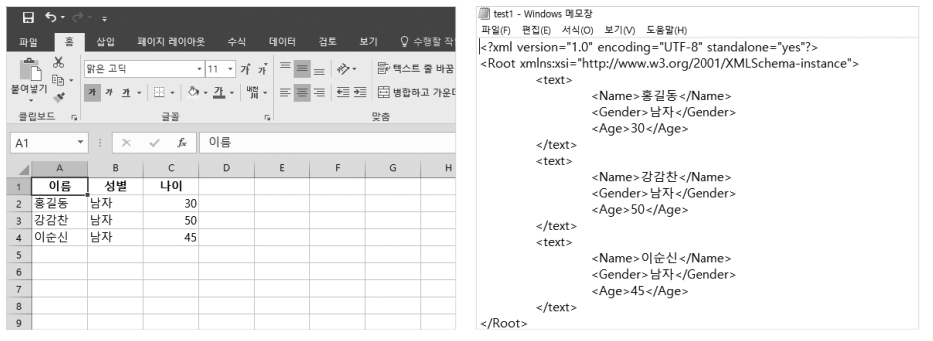

# openpyxl

[openpyxl](https://openpyxl.readthedocs.io/en/stable/index.html)

- openpyxl은 OOXML을 활용하여 만들어진 라이브러리로 이 모듈을 이용하면 엑셀 파일의 내용을 쉽게 변경하거나 엑셀에서 일어나는 단순 반복 작업을 빠르게 처리 할 수 있습니다.
- pandas, numpy 등 파이썬 데이터 처리 모듈과 연계하여 더 효율적인 작업도 가능합니다.
- 엑셀 2010 버전 이후 xlsx 파일 편집 가능
- 엑셀을 다룰 수 있는 라이브러리: pandas, opoenpyxl, xlrd 엑셀을 다양하게 다룰 수 있음

## openpyxl 주요 기능

- 엑셀 파일(워크북) 생성, 수정, 삭제 및 기존 엑셀 파일 불러오기
- 워크시트 생성 및 수정, 행/열 생성 및 수정
- 셀에 들어있는 값과 표시 형식 추가, 수정 및 셀 메모 생성
- 텍스트 서식, 셀 테두리/배경, 셀 크기 등 서식 수정
- 그래프(차트), 피벗테이블 생성 및 수정

참조
엑셀 자동화 모듈인 xlwings. 엑셀을 제어한다는 점에서 openpyxl과 비슷해보이지만 xlwings는 엑셀의 매크로(VBA : Visiaul Basic for Appliacation)와 파이썬을 연동하는 것이 가능합니다.

1. xlwings (기존 매크로 실행 및 연동에 최적)
기존에 만들어둔 **VBA 매크로(.xlsm)**를 파이썬에서 실행해야 하거나, 엑셀 창이 열린 상태에서 실시간으로 데이터를 주고받아야 할 때 사용합니다.

장점: 엑셀을 직접 실행시키므로 VBA 코드를 호출하기 매우 쉽습니다. 엑셀과 파이썬 사이의 '다리' 역할을 합니다.

용도: 기존 매크로 실행, 엑셀 UI를 활용한 자동화.

2. openpyxl (데이터 읽기/쓰기 및 서식 지정)
엑셀 파일(.xlsx)을 직접 열지 않고도 내용을 읽거나 쓰고, 셀 색상, 폰트 등 서식을 변경할 때 가장 많이 쓰입니다.

장점: 엑셀 프로그램이 설치되어 있지 않아도 작동하며, 속도가 빠르고 안정적입니다.

용도: 대량의 데이터 입력, 보고서 양식 만들기, 단순 데이터 추출.

주의: 매크로(.xlsm) 파일의 실행은 불가능하며, 저장 시 매크로가 삭제될 수 있어 주의가 필요합니다.

## openpyxl 설치

In [ ]:
#이미 설치되어 있음 안해도 됨
!pip install openpyxl 
#터미널에서 해도 됨, 맥북 pip3, sudo pip3

## openpyxl 관련 핵심 객체별 주요 함수 정리

### 엑셀 파일의 기본구조

- Workbook: 엑셀 파일 전체를 의미합니다.
- Worksheet: 파일 내의 개별 시트(Tab)입니다.
- Cell: 데이터가 저장되는 최소 단위(A1, B2 등)입니다

### Workbook (wb) 관련: 엑셀 파일 전체 관리
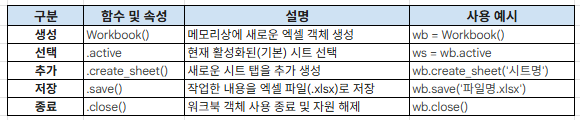

### Worksheet (ws) 관련: 시트 및 데이터 관리
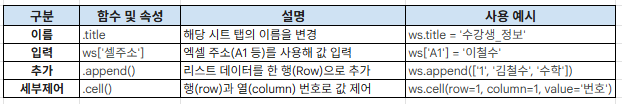


# 엑셀 파일/시트/셀 다루기

## 엑셀 파일 생성 및 저장하기
- WorkBook(): 새 워크북 생성, 생성시 워크시트 하나 기본적으로 추가, 엑셀파일
- wb.active : 현재 활성화된 기본 시트 선택
- wb.save(파일이름): 워크북 저장

In [ ]:
from openpyxl import Workbook

wb = Workbook() # 워크북 객체 생성, 하나의 엑셀 파일
ws = wb.active # 현재 활성화된 워크 시트 선택 기본 sheet
ws['A1'] = '이철수'
wb.save('수강생_리스트.xlsx')
wb.close()

## 엑셀 파일 불러와서 내용 수정 후 저장하기

- load_workbook(파일이름): 엑셀 파일을 불러오기

In [ ]:
from openpyxl import load_workbook

wb = load_workbook('수강생_리스트.xlsx')
ws = wb.active
ws['A2'] = '이영희'

wb.save('수강생_리스트.xlsx')
wb.close()

## 한 행에 데이터 입력하기

In [ ]:
wb = Workbook() # 워크북 객체 생성, 하나의 엑셀 파일
ws = wb.active # 현재 활성화된 워크 시트 선택 기본 sheet

column = ['번호', '이름', '과목'] # 헤더
ws.append(column)
row = [1, '이철수', '수학']
ws.append(row)

wb.save('수강생_리스트.xlsx')
wb.close()

## 여러 행에 데이터 입력하기

In [ ]:
wb = Workbook() # 워크북 객체 생성, 하나의 엑셀 파일
ws = wb.active # 현재 활성화된 워크 시트 선택 기본 sheet

column = ['번호', '이름', '과목'] # 헤더
ws.append(column)
row = [[1, '이철수', '수학'], [2, '최학준', '컴퓨터'], [3, '김미소', '영어']]

for data in row :
    ws.append(data)

wb.save('수강생_리스트.xlsx')
wb.close()

## 시트 생성, 선택, 목록 출력하기

- wb.create_sheet(시트이름): wb 워크북에 시트 추가
- wb.sheetnames: 시트 전체 목록 반환
- ws = wb[시트이름]: 시트선택 시트정보는 Workbook 객체에 딕셔너리 형태로 저장

In [ ]:
wb = load_workbook('수강생_리스트.xlsx')

wb.create_sheet('중간고사')
wb.create_sheet('기말고사')
print(wb.sheetnames)

ws = wb['중간고사']
ws.append(['중간고사 성적 입력란'])

ws = wb['기말고사']
ws.append(['기말고사 성적 입력란'])

wb.save('수강생_리스트.xlsx')
wb.close()

## 시트 이름과 프로퍼티 바꾸기

- wb[시트이름].title = 변경할 시트이름 : 선택한 시트의 이름 변경
- wb[시트이름].sheet_properties.프라퍼티이름 = 변경할 값

In [ ]:
wb = load_workbook('수강생_리스트.xlsx')
ws = wb.active
ws.title = '수강생_정보' # sheet 제목을 수정
wb['중간고사'].title = '중간고사 성적'
wb['중간고사 성적'].sheet_properties.tabColor = 'ff66ff'
wb.active = wb['중간고사 성적']

wb.save('수강생_리스트.xlsx')
wb.close()

## 시트 복사하기


- wb.copy_worksheet(wb[시트이름]): 지정한 시트를 복사하여 wb 객체에 저장

In [ ]:
wb = load_workbook('수강생_리스트.xlsx')
wb.copy_worksheet(wb['기말고사'])
print(wb.sheetnames)

wb.save('수강생_리스트.xlsx')
wb.close()

## 시트 순서 변경하기

- wb.move_sheet(wb[시트이름], offset):offset + 면 오른쪽으로 숫자만큼 이동, - 이면 왼쪽으로 숫자만큼 이동

In [ ]:
wb = load_workbook('수강생_리스트.xlsx')
print(wb.sheetnames)

wb.move_sheet(wb['기말고사'], -1) # -1 : 왼쪽으로 움직인다.
print(wb.sheetnames)

# index 시작은 0
# 안 주면 맨 뒤에 생성
wb.create_sheet('과제', 1)
print(wb.sheetnames)

wb.move_sheet('과제', 1) # 1 : 오른쪽으로 이동
print(wb.sheetnames)

wb.save('수강생_리스트_시트순서변경.xlsx')
wb.close()

## 시트 삭제하기

- wb.remove(wb[시트이름]): 선택한 시트 삭제하기

In [ ]:
wb = load_workbook('수강생_리스트_시트순서변경.xlsx')
print(wb.sheetnames)

wb.remove(wb['기말고사 Copy'])

wb.save('수강생_리스트_시트삭제.xlsx')
print(wb.sheetnames)

wb.close()

## 열 단위로 데이터 입력하기

#### <span style="color: blue;"><u>**cell() : 특정 셀에 접근하여 값 설정하기**</u></span>

- ws.cell(row=1, column=1,value='값' ) column = A - 1, B - 2, C - 3, ...
- column( A - 1, B - 2, C - 3, ...), row 1 부터 시작

In [ ]:
from openpyxl import Workbook

wb = Workbook()
ws = wb.active

ws.title = '수강생_정보'
data = ['이철수', '김미소', '최학준']

for i, value in enumerate(data) :
    ws.cell(row = i + 1, column = 1, value = value) # column 1 = A

wb.save('수강생_리스트.xlsx')
wb.close()

<u>enumerate( ): 리스트와 같은 반복 가능한 객체를 다룰 때, 항목의 순서(인덱스)와 항목의 값을 동시에 반환하는 함수</u>

#### <span style="color: blue;"><u>**ws['A1'] : 셀 주소 지정 방식 활용하기**</u></span>

In [ ]:
wb = load_workbook('수강생_리스트.xlsx')
ws = wb.active

ws.title = '수강생_정보'
data = ['이철수', '김미소', '최학준']

for i, value in enumerate(data) :
    ws[f'B{i + 1}'] = value

wb.save('수강생_리스트.xlsx')
wb.close()

<u>엑셀 열 이름을 번호로 변환하여 사용</u>

In [ ]:
from openpyxl.utils.cell import get_column_letter, column_index_from_string

# 열 이름 얻기
index = 16
print('열 번호 16의 열이름:', get_column_letter(index))
# 열 번호 얻기
print('열 이름 AB의 열 번호:', column_index_from_string('AB'))

#### <span style="color: blue;"><u>**iter_cols( ) : 특정 범위의 열을 순회하기**</u></span>

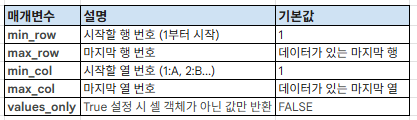

In [ ]:
from openpyxl import Workbook

wb = Workbook()
ws = wb.active
ws.title = '수강생_정보'
data = [ ['이철수', '김미소', '최학준'], ['메이허', '브라이스유', '박현규'] ]

data_cells = ws.iter_cols(min_col = 1, max_col = 2, min_row = 1, max_row = 3)

# 지정된 셀을 순회하면 데이터 입력
for col_idx, col_cells in enumerate(data_cells) :
    for row_idx, cell in enumerate(col_cells) :
        cell.value = data[col_idx][row_idx]

wb.save('수강생_리스트.xlsx')
wb.close()

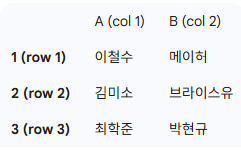

## 셀 내용 확인하기

**[A1] 셀의 값을 출력**
- ws["A1"].value: 
- ws[1][0].value: 1행 0열 
- ws.cell(column=1, row=1).value: column = A - 1, B - 2, C - 3, ...

In [ ]:
from openpyxl import load_workbook

#'월별구매고객리스트.xlsx' 엑셀 파일 불러오기
wb = load_workbook(filename='./data/월별구매고객리스트.xlsx')

# 활성화된 시트 불러온 다음 제목 출력해보기
ws = wb.active

# 'A1' 열을 가져오는 3가지 방법
print(ws['A1'].value)
print(ws[1][0].value) # A가 0열
print(ws.cell(column = 1, row = 1).value)

# row = 1, 2, 3, ...
# column = A - 1, B - 2, C - 3, ...

<u> 셀 값을 가져올때 주위할 점</u>

In [ ]:
# 셀 객체를 반환
print(ws['A1'])

# 셀 객체의 값을 반환
print(ws['A1'].value)


## 셀의 내용 수정하기

- ws[셀이름] = 변경할 값
- ws.cell(column=행인덱스, row=열인덱스, value='변경할 값')

In [ ]:
from openpyxl import load_workbook

wb = load_workbook("수강생_리스트.xlsx")
ws = wb["수강생_정보"]
ws['A1'] = '성명'
ws.cell(column = 1, row = 2, value = '성명2') # A2

wb.save("수강생_리스트_셀수정.xlsx") 	# 파일 저장

## 행과 열 삭제하기

- ws.delete_rows(idx, amount): idx 부터 amount 만큼 행 삭제
- ws.delete_cols(idx, amount): idx 부터 amount 만큼 열 삭제

In [ ]:
from openpyxl import load_workbook	

wb = load_workbook("./data/월별구매고객리스트.xlsx")
ws = wb['10월']
ws.delete_rows(idx = 2, amount = 1) # 2행부터 1행을 삭제
ws.delete_cols(idx = 2, amount = 2) # 두번쨰 열부터(B) 2열 삭제

wb.save("월별구매고객리스트_행열삭제.xlsx")

## 셀 복사하기

In [ ]:
wb = load_workbook("./data/월별구매고객리스트.xlsx")	
ws = wb['10월']

src = ws['B3'].value
ws['A10'] = src

for row in ws['A11:C11'] :
    for cell in row :
        cell.value = src

wb.save("월별구매고객리스트_셀복사.xlsx")

## 셀 내용 이동하기

- ws.move_range(이동할 범위, rows , cols ): 음수 위, 왼쪽, 양수 아래 오른쪽으로 이동

In [ ]:
from openpyxl import load_workbook		
wb = load_workbook("./data/월별구매고객리스트.xlsx")		
ws = wb['10월']							

# [B1:C3] 영역에 있는 데이터를 아래로 세 칸, 왼쪽으로 1칸 이동
ws.move_range('B6:F7', rows = 3, cols = -1)


wb.save("월별구매고객리스트_셀이동.xlsx")	

## 셀 병합 및 해제하기

- ws.merge_cells(병합할 셀범위): 셀 병합
- ws.unmerge_cells(해제할 셀범위): 셀 병합 해제

In [ ]:
from openpyxl import load_workbook		
wb = load_workbook("./data/월별구매고객리스트.xlsx")		
ws = wb['10월']

# A1, A2 셀 병합
ws.merge_cells('A1:A2')
wb.save("월별구매고객리스트_셀병합.xlsx")

In [ ]:
# A1, A2  셀 병합 해제
ws.unmerge_cells('A1:A2')
wb.save("월별구매고객리스트_셀병합해제.xlsx")	

## 셀 연산하기

- 엑셀함수로 연산 하거나 파이썬의 내장함수, pandas의 연산함수로 쉽게 구현 가능

In [ ]:
from openpyxl import load_workbook		
wb = load_workbook("./data/월별구매고객리스트.xlsx")		
ws = wb['10월']

ws['G8'] = '총 매출액'
ws['H8'] = '=sum(H3:H7)'

wb.save("월별구매고객리스트_셀연산.xlsx")

# 엑셀 데이터 읽기

## 시트 전체 데이터 가져오기

- ws.rows: 시트의 모든 행을 순회할 수 있는 객체를 만듦

In [ ]:
from openpyxl import load_workbook

wb = load_workbook(filename='./data/월별구매고객리스트.xlsx')
ws = wb['10월']
# 시트의 모든 행을 순회
for row in ws.rows :
    row_values = [cell.value for cell in row]
    print(row_values)

    # 이렇게 for문을 써도 상관없다.
    # for cell in row :
    #     print(cell.value, end = '')
    # print()

## 특정 행을 지정하여 가져오기

#### <span style="color: blue;"><u>**리스트 슬라이싱으로 특정 행 가져오기**</u></span>

In [ ]:
from openpyxl import load_workbook

wb = load_workbook(filename='./data/월별구매고객리스트.xlsx', data_only=True) # data_only=True : 계산식이 아니라 계산된 값 출력
ws = wb['10월']

s_rows = list(ws.rows)[2:]

for row in s_rows :
    row_values = [cell.value for cell in row]
    print(row_values)    

#### <span style="color: blue;"><u>**iter_rows( ) : 특정 범위의 행 순회하기**</u></span>

- 매개변수 values_only=True는 셀의 주소나 스타일 같은 정보는 제외하고, 그 안에 들어있는 실제 데이터(값)만 튜플 형태로 뽑아오겠다는 뜻

반복 가능한 객체(Iterable)는 "내부의 요소들을 한 번에 하나씩 차례대로 꺼낼 수 있는 모든 객체"

In [ ]:
from openpyxl import load_workbook

wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

# 세번째 행부터 마지막 행까지 읽기
for row in ws.iter_rows(min_row=3, values_only=True) : # values_only = True : 값만 나오게 해라
    print(row)

## 수식을 제외한 결괏값 가져오기

- load_workbook()함수의 매개변수 data_lonly = True: 수식이 아닌 엑셀에서 보여주는 결과값을 가져옴

In [ ]:
from openpyxl import load_workbook

wb = load_workbook('./data/월별구매고객리스트.xlsx', data_only=True)
ws = wb['10월']

# 세번째 행부터 마지막 행까지 읽기
for row in ws.iter_rows(min_row=3, values_only=True) : # values_only = True : 값만 나오게 해라
    print(row)



## 열을 지정하여 데이터 가져오기

#### <span style="color: blue;"><u>**인덱싱으로 특정 열 가져오기**</u></span>

In [ ]:
from openpyxl import load_workbook
wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

# 모든 행의 1, 2 열 출력
for row in ws.rows :
    print(row[1].value, row[2].value)

#### <span style="color: blue;"><u>**iter_cols( ) : 특정 범위의 열 순회하기**</u></span>

In [ ]:
from openpyxl import load_workbook
wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

for col in ws.iter_cols(min_col=2, max_col=3, min_row=3, values_only=True) :
    print(col)

In [ ]:
from openpyxl import load_workbook
wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

# 세 번째 행부터 마지막까지 B열과 C열 데이터 출력하기
for col in ws.iter_cols(min_col=2, max_col=3, min_row=3) :
    for cell in col :
        print(cell.value)

## 조건으로 데이터 가져오기

In [ ]:
from openpyxl import load_workbook

wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

d_rows = list(ws.rows)[2:]

for row in d_rows :
    if row[2].value >= 2 :
        print(row[1].value, row[2].value)

In [ ]:
# 빈값을 조건으로 비교하면 오류가 발생!!!
from openpyxl import load_workbook

wb = load_workbook('./data/월별구매고객리스트.xlsx')
ws = wb['10월']

for row in ws.rows :
    if row[2].value >= 2 :
        print(row[1].value, row[2].value)

## 암호화된 엑셀 파일 다루기

### msoffcrypto-tool 라이브러리

- msoffcrypto-tool은 비밀번호로 보호된 Microsoft Office 파일(Excel, Word, PowerPoint 등)을 복호화(암호 해제)해주는 파이썬 라이브러리입니다.
- 핵심 역할: 암호화된 파일을 읽어서, 메모리 상에 암호가 풀린 가상의 파일을 만들어줍니다.
- 필요성: openpyxl이나 pandas는 암호화된 파일을 직접 여는 기능이 없기 때문에, 이 라이브러리가 먼저 암호를 풀어줘야 데이터를 읽을 수 있습니다.

In [56]:
!pip install msoffcrypto-tool

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------  3.4/3.5 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 18.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cryptography]
   ---------------------------------------- 3/3 [msoffcrypto-tool]



In [60]:
import msoffcrypto
from openpyxl import load_workbook
import os

#엑셀 파일은 바이너리 형식의 파일 바이너리 형식으로 읽고 써야함
# 암호화된 엑셀 파일을 바이너리 읽기 모드로 열고
# msoffcrypto.OfficeFile 객체 생성
file =msoffcrypto.OfficeFile(open('./data/월별구매고객리스트_잠김.xlsx', 'rb'))


# 파일의 암호 설정. '1234'는 암호화된 파일의 비밀번호
file.load_key(password='1234')

# 암호화된 파일을 해제하고 새로운 파일로 저장
with open('월별구매고객리스트_잠김해제.xlsx', 'wb') as f:
 file.decrypt(f)

# 암호 해제된 파일 열기
wb = load_workbook('월별구매고객리스트_잠김해제.xlsx')
ws = wb.active

# 시트의 모든 행을 순회하며 값을 출력
for row in ws.iter_rows(values_only=True):
 print(row)

# 암호 해제된 임시 파일 삭제
os.remove('월별구매고객리스트_잠김해제.xlsx')

('10월', None, None, None, None, None, None, None)
('구매일자', '구매제품', '수량', '고객명', '소속', '기존고객여부', '단가', '매출액')
(datetime.datetime(2023, 10, 3, 0, 0), 'A제품', 2, '김철원', '최강회사', '기존', 20000, '=C3*G3')
(datetime.datetime(2023, 10, 16, 0, 0), 'B제품', 1, '이남연', '다알아연구소', '신규', 18000, '=C4*G4')
(datetime.datetime(2023, 10, 22, 0, 0), 'B제품', 1, '최연화', '일일컴퍼니', '신규', 18000, '=C5*G5')
(datetime.datetime(2023, 10, 29, 0, 0), 'C제품', 4, '황수지', '소속 없음', '신규', 36000, '=C6*G6')
(datetime.datetime(2023, 10, 29, 0, 0), 'D제품', 2, '유진태', '소속 없음', '기존', 68000, '=C7*G7')


# 엑셀 서식 설정하기

- openpyxl.styles 서브패키지

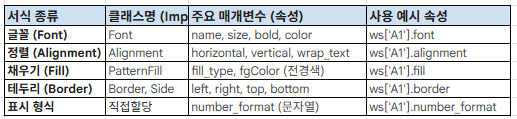

## 폰트 서식 설정하기

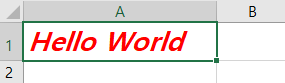

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font

wb = Workbook()
ws = wb.active

cell = ws['A1']
cell.value = 'Hello World'

# 글꼴 속성을 인자로 전달하여 Font 클래스의 객체를 생성
# 생성된 Font 객체를 셀의 font 속성에 할당하여 셀에 글꼴 적용
cell.font = Font(color='FF0000', italic=True, bold=True, size=20)

wb.save('엑셀 서식.xlsx')

## 열과행의 너비와 높이, 배경색, 테두리, 정렬 서식 설정하기

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font
from openpyxl.styles import PatternFill, Border, Side, Alignment

wb = Workbook()
ws = wb.active
cell = ws['A1']
cell.value = 'Hello World'
### Font
cell.font = Font(color='FF0000',
        italic=True,
        bold=True,
        size=20)

### 열의 너비, 행의 높이
# A열의 너비를 50으로 설정
ws.column_dimensions['A'].width = 50 # 단위가 글자 수 단위

# 1행의 높이를 50으로 설정
ws.row_dimensions[1].height = 50 # 단위가 point

### 셀 배경색을
yellow_fill = PatternFill(start_color='FFFF00', end_color='FFFF00', fill_type='solid')

#'solid': 무늬 없이 색상을 면 전체에 꽉 채우는 방식
cell.fill = yellow_fill

### 셀 테두리 설정, 모든 사이드에 얇은 테두리 스타일 적용
thin_side = Side(style='thin')
cell.border = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)

### 셀 정렬 설정, 셀 내용을 수평 및 수직 중앙 정렬
cell.alignment = Alignment(horizontal='center', vertical='center')
wb.save('엑셀 서식.xlsx')

## 데이터 형식 설정하기

- \# (샵): 유효한 자릿수만 표시합니다. (천 단위 쉼표와 결합할 때 주로 사용)
- 0 (영): 값이 없어도 해당 자릿수를 0으로 강제 채움합니다. (소수점 자릿수 고정에 필수!)
- , (쉼표): 숫자 사이에 넣으면 천 단위 구분 기호를 표시하라는 명령입니다.
- "..." (따옴표): 서식 안에 특수문자나 텍스트를 넣고 싶을 때 사용합니다. (예: #,##0"명")

In [68]:
from openpyxl import Workbook
from datetime import datetime

wb = Workbook()
ws = wb.active


ws['A1'] = 1234567.890123
ws['A1'].number_format = '#.##0.00' # 천 단위 구분기호, 소수점 둘째 자리까지 표시

ws['B1'] = 1234567.89
ws['B1'].number_format = '₩#, ##0' # 등가기호 천 단위 구분, 반올림해서 정수 표시

ws['D1'] = 0.12345
ws['D1'].number_format = '0.00%' # 퍼센트 형식으로, 소수 둘째자리까지 표시

ws['C1'] = datetime(2023, 9, 7)
ws['C1'].number_format = 'MM-DD-YYYY'

wb.save('표시 형식 설정.xlsx')

# 조건에 맞는 데이터 선별하여 재분류하기

- 실무에서 한 파일의 데이터를 복사하여 다른 엑셀 파일에 붙여넣거나 여러파일을 하나로 합쳐햐하는 경우가 많습니다.
- 주기적으로 발생하거나 다량의 파일을 작업해야 한다면 다동화하는 것이 효율적입니다.

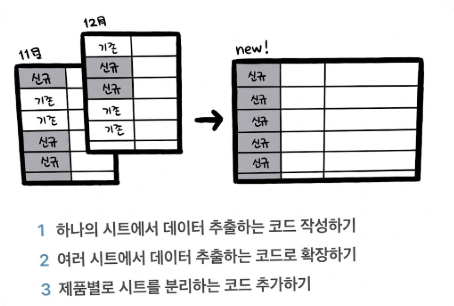

## 하나의 시트에서 데이터 추출하는 코드 작성하기

In [1]:
from openpyxl import load_workbook

# 파일의 '10월' 시트에서 처음 2개 행을 제외한 표 데이터 부분만 가져오기
wb = load_workbook('./data/월별구매고객리스트.xlsx', data_only=True)
ws = wb['10월']
new_rows = list(ws.rows)[2:]

#  F열이 '신규'인 데이터만 추출
for row in new_rows:
    if row [5].value == '신규' :
        row_values = [cell.value for cell in row]
        print(row_values)

wb.save(filename='제품별신규고객리스트.xlsx')

[datetime.datetime(2023, 10, 16, 0, 0), 'B제품', 1, '이남연', '다알아연구소', '신규', 18000, 18000]
[datetime.datetime(2023, 10, 22, 0, 0), 'B제품', 1, '최연화', '일일컴퍼니', '신규', 18000, 18000]
[datetime.datetime(2023, 10, 29, 0, 0), 'C제품', 4, '황수지', '소속 없음', '신규', 36000, 144000]


## 여러 시트에서 데이터 추출하는 코드로 확장하기

In [2]:
from openpyxl import load_workbook

wb = load_workbook(filename='./data/월별구매고객리스트.xlsx', data_only=True)

# 월별 시트 목록을 리스트 형태로 저장
months = ['10월', '11월', '12월']
# 각 월 시트에서 데이터를 추출
for month in months :
    ws = wb[month]
    new_rows = list(ws.rows)[2:]

    #  F열이 '신규'인 데이터만 추출
    for row in new_rows:
        if row [5].value == '신규' :
            row_values = [cell.value for cell in row]
            print(row_values)

wb.save(filename='제품별 신규 고객 리스트.xlsx')

[datetime.datetime(2023, 10, 16, 0, 0), 'B제품', 1, '이남연', '다알아연구소', '신규', 18000, 18000]
[datetime.datetime(2023, 10, 22, 0, 0), 'B제품', 1, '최연화', '일일컴퍼니', '신규', 18000, 18000]
[datetime.datetime(2023, 10, 29, 0, 0), 'C제품', 4, '황수지', '소속 없음', '신규', 36000, 144000]
[datetime.datetime(2023, 11, 16, 0, 0), 'C제품', 1, '윤서원', '㈜서원', '신규', 36000, 36000]
[datetime.datetime(2023, 11, 28, 0, 0), 'A제품', 1, '윤서우', '주식회사 라이언', '신규', 20000, 20000]
[datetime.datetime(2023, 11, 30, 0, 0), 'A제품', 2, '이도준', '아름대학교', '신규', 20000, 40000]
[datetime.datetime(2023, 12, 17, 0, 0), 'C제품', 1, '최민은', '아자코퍼레이션', '신규', 36000, 36000]
[datetime.datetime(2023, 12, 22, 0, 0), 'B제품', 1, '박서은', '상상대학교', '신규', 18000, 18000]
[datetime.datetime(2023, 12, 27, 0, 0), 'A제품', 4, '임지은', '주식회사 지은', '신규', 20000, 80000]


## 제품별로 시트를 분리하는 코드 추가하기 

In [3]:
from openpyxl import load_workbook, Workbook

# 엑셀 파일 불러오기
wb = load_workbook('./data/월별구매고객리스트.xlsx', data_only=True)

#  새로운 엑셀 파일 생성
new_wb = Workbook()
new_ws = new_wb.active

#  월별 시트 목록을 리스트 형태로 저장
months = ['10월', '11월', '12월']

#  각 월 시트에서 데이터를 추출
for month in months:
  ws = wb[month]
  index_row = [cell.value for cell in list(ws.rows)[1]]  # 원본 파일의 두 번째 행(표의 헤더)
  cnt_rows = list(ws.rows)[2:] # 처음 2개 행을 제외하고 나머지 행을 리스트로 변환

  for row in cnt_rows :
    if row[5].value == '신규' :
      product = row[1].value

      if product not in new_wb.sheetnames :
        new_wb.create_sheet(title=product)
        p_ws = new_wb[product]
        p_ws.append(index_row)

      p_ws = new_wb[product]
      p_ws.append([cell.value for cell in row]) # 헤더


#  기본 생성되는 시트 삭제
del new_wb['Sheet']
new_wb.save(filename='제품별신규고객리스트.xlsx')

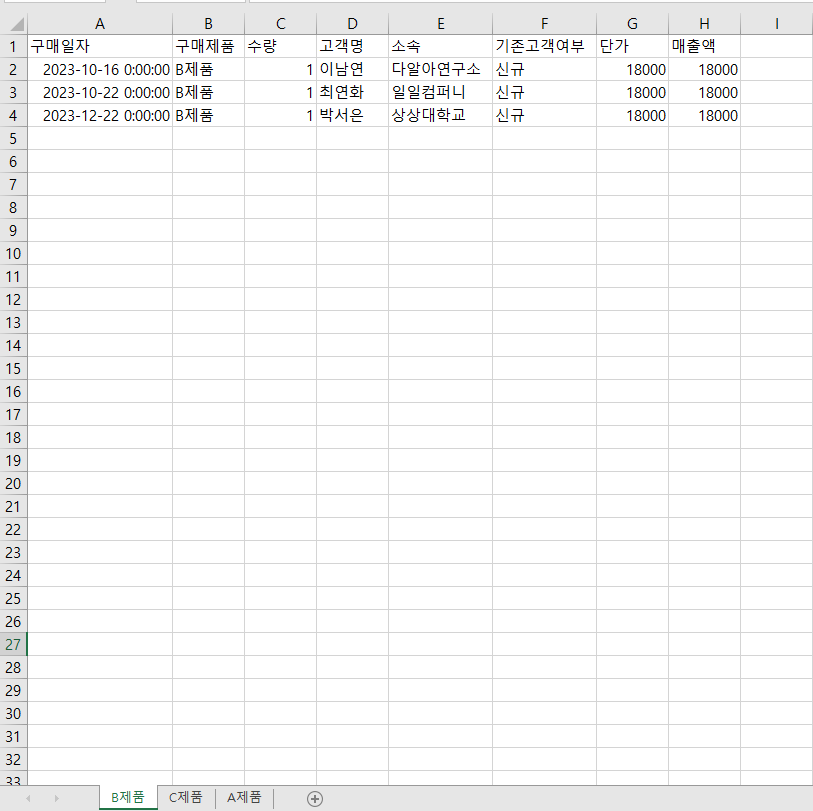

# 엑셀 합치기

## 여러 파일을 하나로 합치기

In [ ]:
from openpyxl import Workbook, load_workbook
import os

# 새로운 엑셀 파일 생성
new_wb = Workbook()
new_ws = new_wb.active
new_ws.title = '수신내역'

# 헤더 행 추가
new_ws.append(['수신시간', '발신번호', '페이지수', '용량'])

# fax 폴더의 모든 파일 목록을 가져와 각 파일을 순회
for filename in os.listdir('./data/fax') :
    wb = load_workbook('./data/fax/' + filename)
    ws = wb.active

    # 두 번째 데이터 행 부터 가져와서 추가
    for row in ws.iter_rows(min_row=2, values_only=True) :
        new_ws.append(row)

# 새로운 엑셀 파일 저장
new_wb.save('10월팩스수신내역.xlsx')

# [실습] 여러 개의 엑셀 판매보고서 합치기

A 사원은 여러 개의 대리점을 관리하고 있습니다. 매일 저녁 각 대리점에서 오늘 판매금액을 엑셀 파일로 보고 합니다. 이 보고서들을 하나로 합쳐서 오늘의 판매금액을 계산하고 보고하는 일을 자동화하는 코드를 작성해보세요.

아래의 판매보고서들을 판매보고서 폴더를 만들고 복사한다.

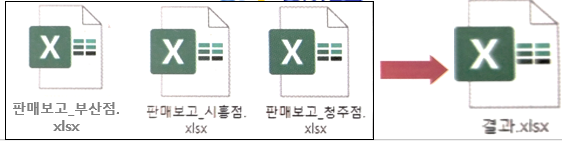

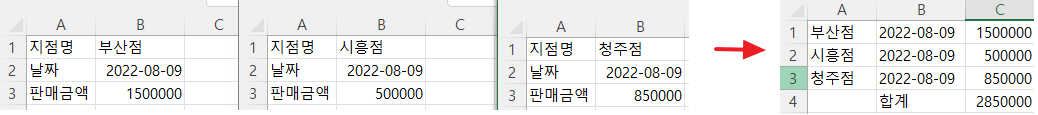

- os 모듈을 이용해서 해당 폴더의 판매보고서 파일을 찾아 리스트로 반환
- r은 Raw String을 의미로 "백슬래시(\)를 특수한 기능을 하는 기호가 아니라, 보이는 그대로의 일반 문자로 취급하라는 뜻

In [16]:
import os
Dir = r'.\data\판매보고서'
fileEx = '.xlsx'

sale_reports = os.listdir(Dir)
sale_reports
    

['판매보고_부산점.xlsx', '판매보고_시흥점.xlsx', '판매보고_청주점.xlsx']

- 판매보고서 데이터를 읽어와서 결과 엑셀파일에 추가하고 총합계 계산

In [17]:
from openpyxl import load_workbook
from openpyxl import Workbook
import os

Dir = r'.\data\판매보고서'
fileEx = '.xlsx'
sale_reports = os.listdir(Dir)
sale_reports

sale_list = []
date_list = []
sale_amount_list = []

for report in sale_reports :
    wb = load_workbook('./data/판매보고서/' + report, data_only=True)
    ws = wb.active
    sale_list.append(ws['B1'].value)
    date_list.append(ws['B2'].value.strftime('%Y-%m-%d'))
    sale_amount_list.append(ws['B3'].value)

try :
    wb = load_workbook('./data/판매보고서/결과.xlsx', data_only=True)
    ws = wb.active
except :
    wb = Workbook()
    ws = wb.active

for i in range(len(sale_list)) :
    ws.cell(row=i + 1, column=1).value = sale_list[i]
    ws.cell(row=i + 1, column=2).value = date_list[i]
    ws.cell(row=i + 1, column=3).value = sale_amount_list[i]

ws.cell(row=ws.max_row + 1, column=2).value = '합계'
ws.cell(row=ws.max_row + 1, column=3).value = '=sum(C1:C3)'

wb.save(r'.\data\판매보고서\결과.xlsx')

# [실습] 여러 개의 엑셀 파일을 하나로 합치기 - 시트 합치기

- 다른 엑셀파일 사이에서 시트복사가 되지 않으므로 복사하는 함수를 만들어서 시트를 합쳐보자
- 부서1.xlsx, 부서2.xlsx 파일의 시트를 통합.xlsx파일을 만들어 합쳐 봅니다.

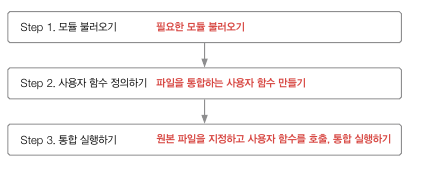

In [ ]:
# 01. 모듈 불러오기
from copy import copy	# 셀의 값과 서식을 복사하기 위해 copy 모듈 불러오기
from openpyxl import Workbook
from openpyxl import load_workbook

In [ ]:
# 02. 사용자 함수 정의하기 1
def copy_ws(ws_src, wb_dst, new_sheet_name):
    
    # 값 복사 (iter_rows 활용)
    
        
    # 병합 정보만 따로 복사
    

In [ ]:
# 02. 사용자 함수 정의하기 2
def copy_ws(ws_src, wb_dst, new_sheet_name):  
    

In [ ]:
# 03. 통합 실행하기

wb_dst.save("통합.xlsx")


# [실습] 견적서로 거래명세서 자동 생성하기

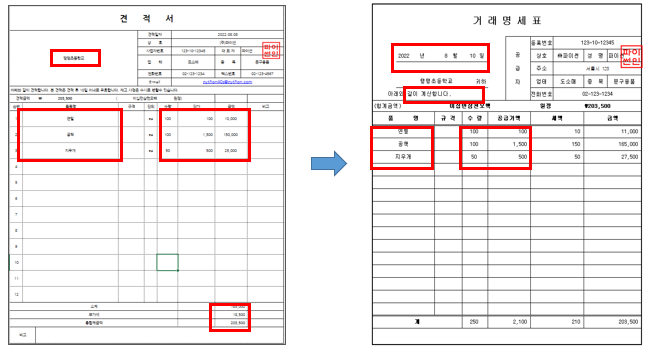

현재 폴더에 견적서 폴더를 만들고 견적서_땡땡초등학교.xlsx, 거래명세표_샘플.xlsx를 복사한다.

- 견적서의 내용을 읽어서 리스트로 반환

In [ ]:
from openpyxl import load_workbook
from openpyxl.utils import column_index_from_string

# 1. 파일 불러오기 (data_only=True로 설정해야 수식이 아닌 계산된 값을 가져옴)
file_path = r".\견적서\견적서_땡땡초등학교.xlsx"


print("품목명:", 품목명_list)
print("수량:", 수량_list)
print("단가:", 단가_list)
print("금액:", 금액_list)

- 위에 견적서에서 읽어온 데이터로 거래명세서를 만든다.

In [ ]:
from datetime import date
from openpyxl import load_workbook
from openpyxl.utils import column_index_from_string

# 1. 파일 불러오기 및 시트 선택
file_path2 = r".\견적서\거래명세표_샘플.xlsx"


print(f"파일 저장 완료: {save_name}")

# [실습] 유통매장의 고객만족도 분석하기

유통매장에서 일하는 있는 모사원은 매주 고객들의 제품 구매 만족도와 클레임 횟수를 조사 및 정리하여 상사에게 보고 하고 있습니다. 조사하는 데이터의 값 양만 달라질 뿐, 동일한 양식에 값을 채워넣고 평균과 합계를 내는 지루한 작업이 매주 반복되고 있습니다. 파이썬으로 자동화하는 코드를 작성해보세요

- 고객 만족 데이터.xlsx 현재 폴더에 복사하기 

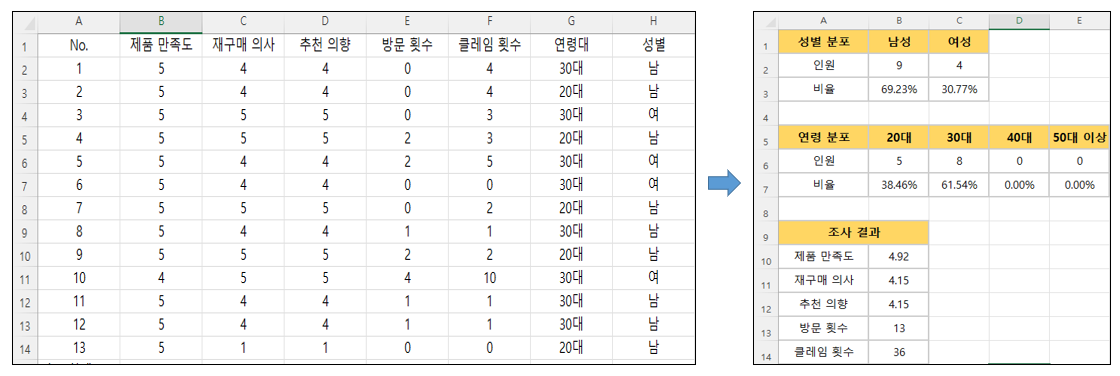

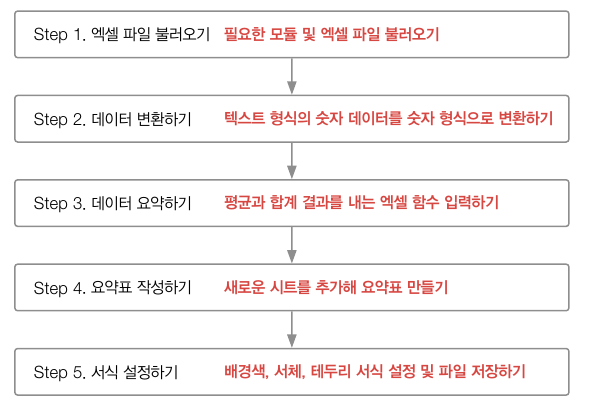

In [ ]:
# 01. 엑셀 파일 불러오기 (힌트: load_workbook) -> 고객 만족 데이터.xlsx

from openpyxl import load_workbook		
	
						

In [ ]:
# 02. 데이터 변환하기
#반복문을 활용해 [B2:F14] 범위의 설문 응답 데이터만 숫자 형식으로 변경

wb.save("고객 만족 데이터.xlsx")

In [ ]:
# 03. 데이터 요약하기

wb.save("고객 만족 데이터.xlsx")

In [ ]:
# 04.요약표 작성하기

wb.create_sheet("요약표") 	
ws = wb["요약표"] 			

# 요약표에 들어갈 내용을 리스트로 미리 지정 
summary_table_form = [
    ["성별 분포", "남성", "여성"],
    ["인원", "", ""],
    ["비율", "", ""],
    ["", "", ""],
    ["연령 분포", "20대", "30대", "40대", "50대 이상"],
    ["인원", "", ""],
    ["비율", "", ""],
    ["", "", ""],
    ["조사 결과"],
    ["제품 만족도"],
    ["재구매 의사"],
    ["추천 의향"],
    ["방문 횟수"],
    ["클레임 횟수"]
]

# 리스트 데이터를 하나씩 읽어와 append() 함수를 통해 내용 입력


wb.save("고객만족데이터요약.xlsx")

In [ ]:
# 1. 성별 요약 (B:남, C:여)


# 2. 연령대 요약 (B:20대 ~ E:50대 이상)

# 3. 항목별 평균/합계 요약 (세로 나열)
# 10행부터 B열에 순서대로 Sheet1의 B~F열 마지막 행 값을 가져옴


wb.save("고객만족데이터요약.xlsx")

In [ ]:
# 05. 서식 설정하기
## 셀의 너비와 높이 조정


wb.save("고객만족데이터요약.xlsx")


In [ ]:
## 테두리 설정
from openpyxl.styles import Alignment, Side, Border, Font, PatternFill, Color

alignment_style = Alignment(horizontal= "center", vertical = "center") # 텍스트 정렬 서식 지정
side = Side(color="CCCCCC", border_style="medium")	# 테두리 서식 지정
border_style = Border(								# border_style 객체 생성
    left = side,
    right = side,
    top = side,
    bottom = side,
)

# 표가 있는 부분에만 폰트와 테두리 서식 적용
style_apply_cells = ["A1:C3", "A5:E7", "A9:B14"] 
for cell_area in style_apply_cells:					# 셀 영역을 차례로 읽어 옴
    for row in ws[cell_area]:						# 셀 영역의 각 행을 차례로 읽어 옴
        for cell in row:							# 행의 각 셀에 접근
            cell.alignment = alignment_style		# 텍스트 서식 설정
            cell.border = border_style				# 테두리 서식 설정

wb.save("고객만족데이터요약.xlsx")


In [ ]:
## 폰트 색채우기
header_font_style = Font(sz = 12, bold = True) 	# 표의 헤더 부분은 볼드로 처리
header_background_style = PatternFill(fill_type = "solid", start_color = "ffd663") # 음영 처리
style_apply_cells_for_header = ["A1:C1", "A5:E5", "A9:B9"] # 서식이 적용될 헤더 부분의 영역 설정

for cell_area in style_apply_cells_for_header:		# 셀 영역을 차례로 읽어 옴
    for row in ws[cell_area]:						# 셀 영역의 각 행을 차례로 읽어 옴
        for cell in row:							# 행의 각 셀에 접근
            cell.font = header_font_style			# 셀 폰트 서식 설정
            cell.fill = header_background_style		# 셀 배경 서식 설정

wb.save("고객만족데이터요약.xlsx")


In [ ]:
# ’조사 결과’ 셀 병합


wb.save("고객만족데이터요약.xlsx")
